### Libraries and functions importation

In [1]:
import sys
sys.path.append("../src")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


from preprocessing import preprocesamiento
from data_splitting import train_val_split
from plots import eda_visualizacion_suvs

### EDA

**Preprocessing**

In [2]:
data = pd.read_csv('../data/pf_suvs.csv')

In [3]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0    Marca    Modelo     Año                          Versión  \
3912         3912  Renault    Duster  2013.0       1.6 4x2 Confort Plus 110cv   
5721         5721  Peugeot      3008  2019.0        1.6 Gt-line Thp Tiptronic   
6085         6085     Ford  Ecosport  2019.0          2.0 Gdi Storm 170Cv 4X4   
13355       13355    Dodge   Journey  2016.0  2.4 Sxt 170cv Atx6 (techo, Dvd)   
6534         6534      BMW        X1  2019.0            2.0 Sdrive 18i Active   

       Color Tipo de combustible  Puertas Transmisión Motor  \
3912   Verde               Nafta      5.0      Manual   1.6   
5721    Gris               Nafta      5.0  Automática   1.6   
6085    Gris               Nafta      5.0  Automática   2.0   
13355  Negro               Nafta      5.0  Automática   2.4   
6534    Gris               Nafta      5.0      Manual   2.0   

      Tipo de carrocería Con cámara de retroceso Kilómetros  \
3912                 SUV                     NaN   

In [4]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [5]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


ESCRIBIR LO QEU VAMOS A HACER EJ ONE HOT POR LAS FEATURES CATEGORICAS ETC

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el train del modelo.***

- solo hacer limpieza de columnas de suvs 
- pasar de de pesoss a dolar y la borramos  
- col 0 km y usados , 0  1 
- eliminamos lass filas 0 de motor 
- ponemos en puertas todo 5
- pasar con one hot a trsmision 
- borramos unnamed 


DESPUES DEL SPLIT
- moda de color 
- moda de camara 



In [6]:
data_pre= preprocesamiento(data)
data_pre.shape

(18216, 15)

**NUEVO DATASET**

In [7]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())
print("\n VALORES FALTANTES")
print(data_pre.isna().sum())


 Dataset NUEVO, ALEATORIO
           Marca        Modelo     Año  \
15005    Renault        Duster  2025.0   
10169  Chevrolet       Tracker  2018.0   
5646       Honda          HR-V  2017.0   
17751        BMW            X6  2025.0   
9032        Audi  Q3 Sportback  2025.0   

                                       Versión     Color Tipo de combustible  \
15005  1.3 Tce Turbo Iconic 155Cv Cvt X-Tronic      Gris               Nafta   
10169                            1.8 Ltz 140cv      Gris               Nafta   
5646                            1.8 Lx 2wd Cvt  Plateado               Nafta   
17751             3.0 Xdrive 40I M Sport 381Cv      Azul         Mild Hybrid   
9032                  2.0 40Tfsi Quattro 190Cv      Gris               Nafta   

       Puertas Transmisión Motor Con cámara de retroceso  Kilómetros  \
15005      5.0  Automática   1.3                      Sí         0.0   
10169      5.0  Automática   1.8                      No     69000.0   
5646       5.0  Automát

**VISUALIZACION DEL EDA HASTA AHORA**

Distribuciones individuales


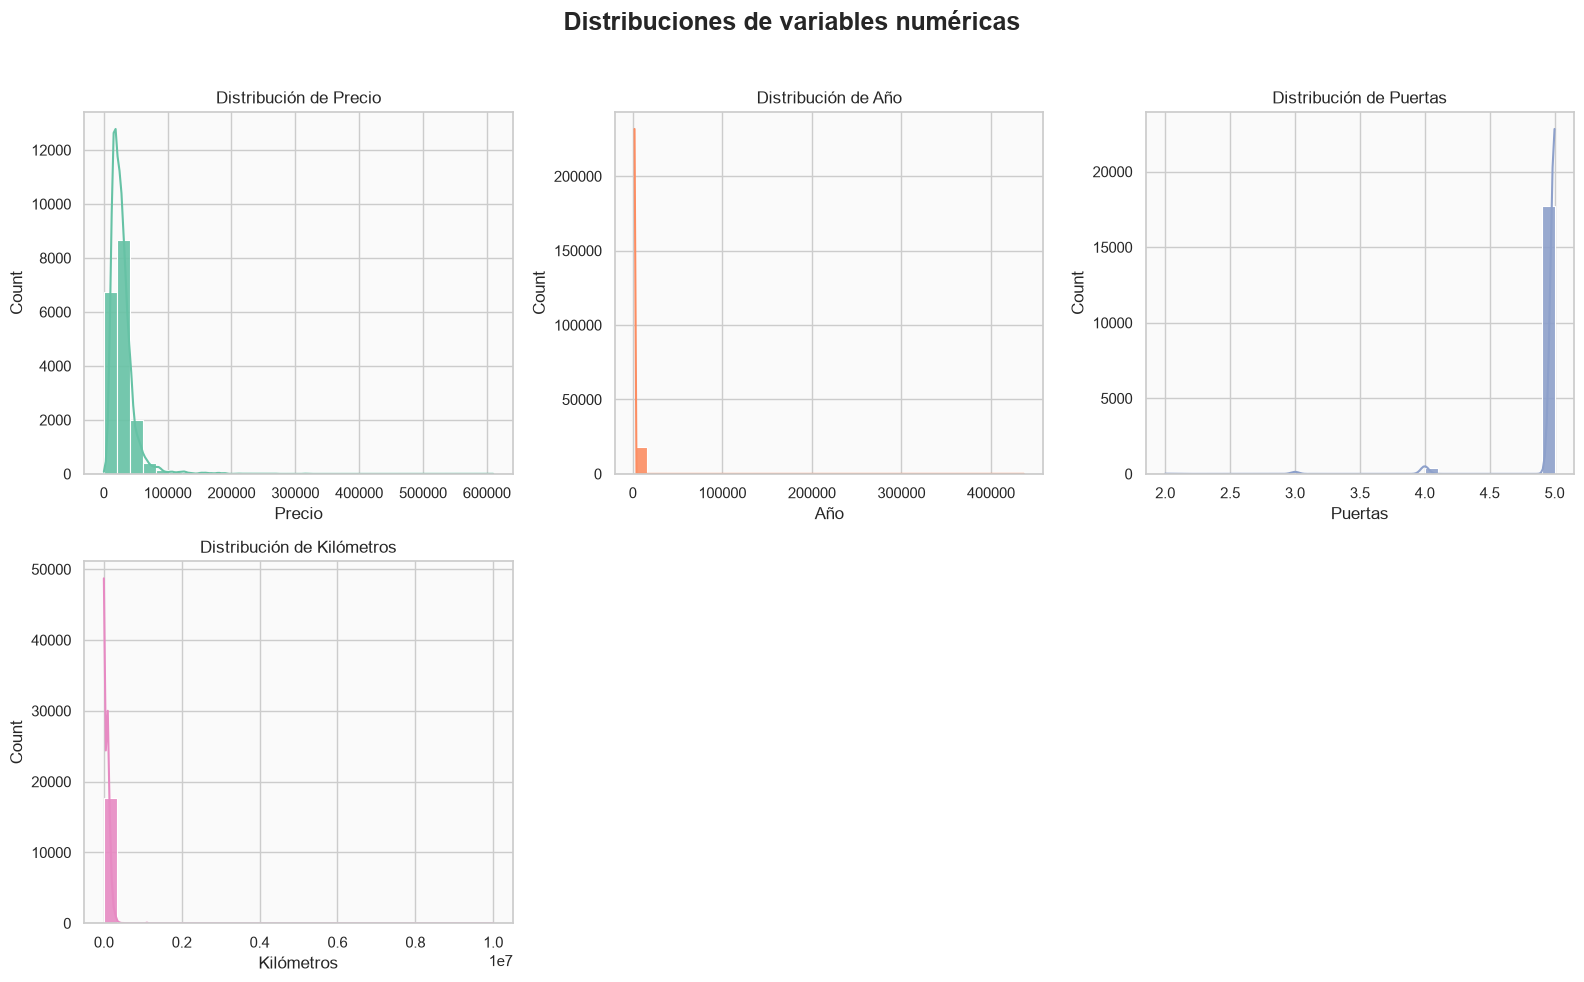

Boxplots individuales


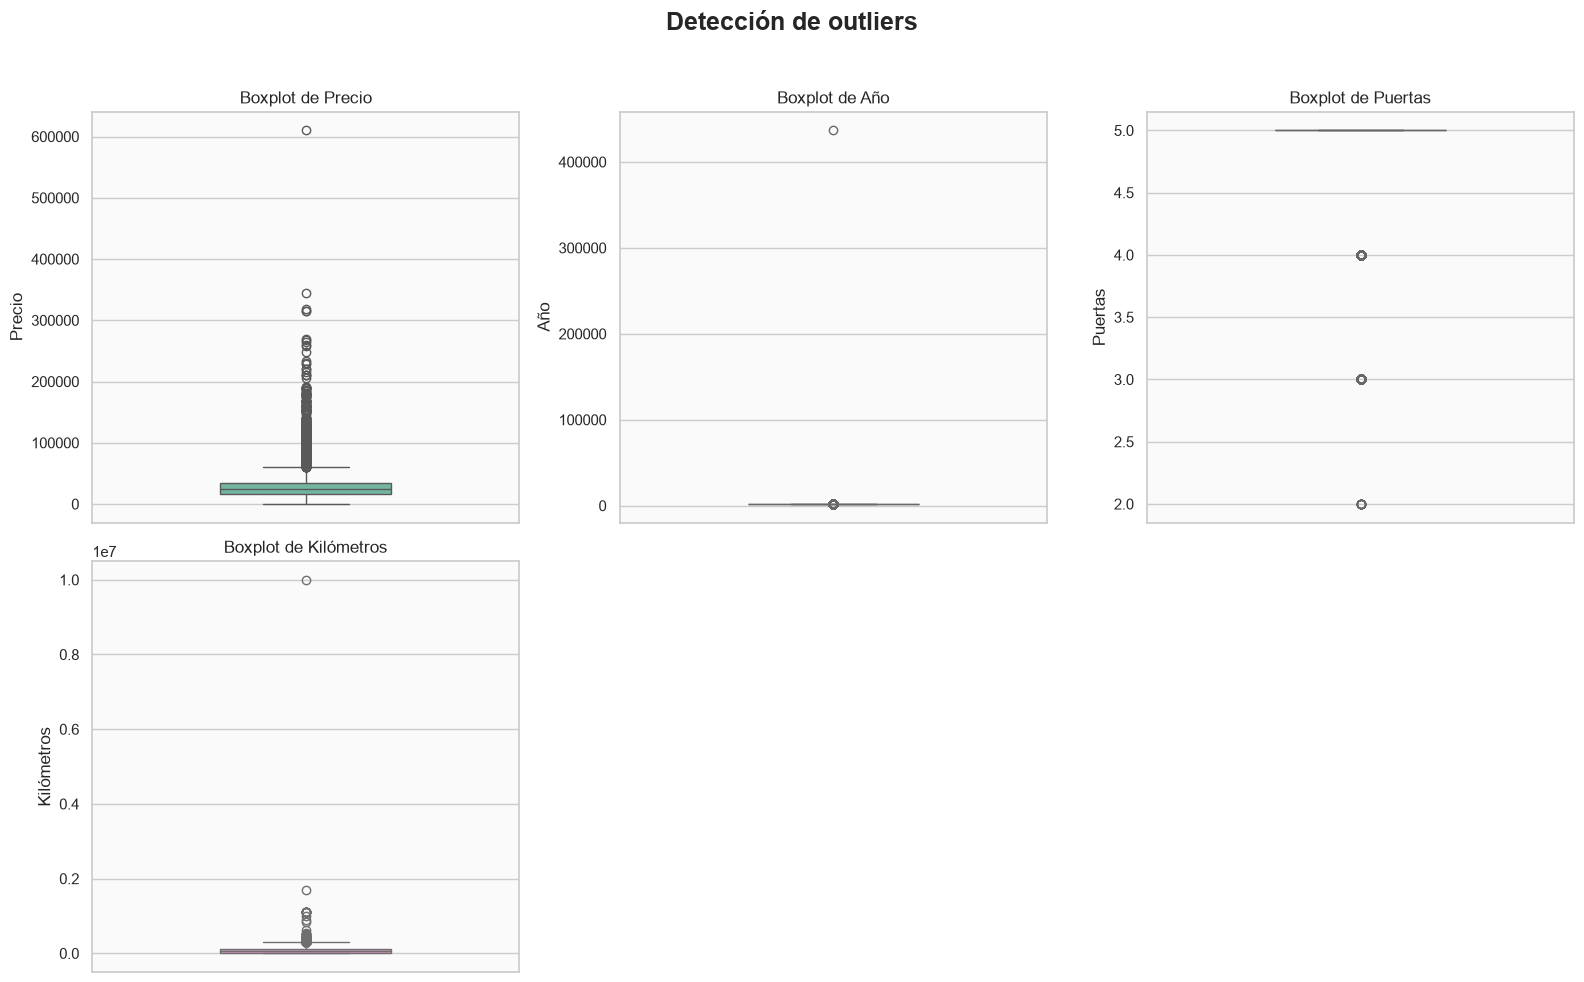

Relación con el precio


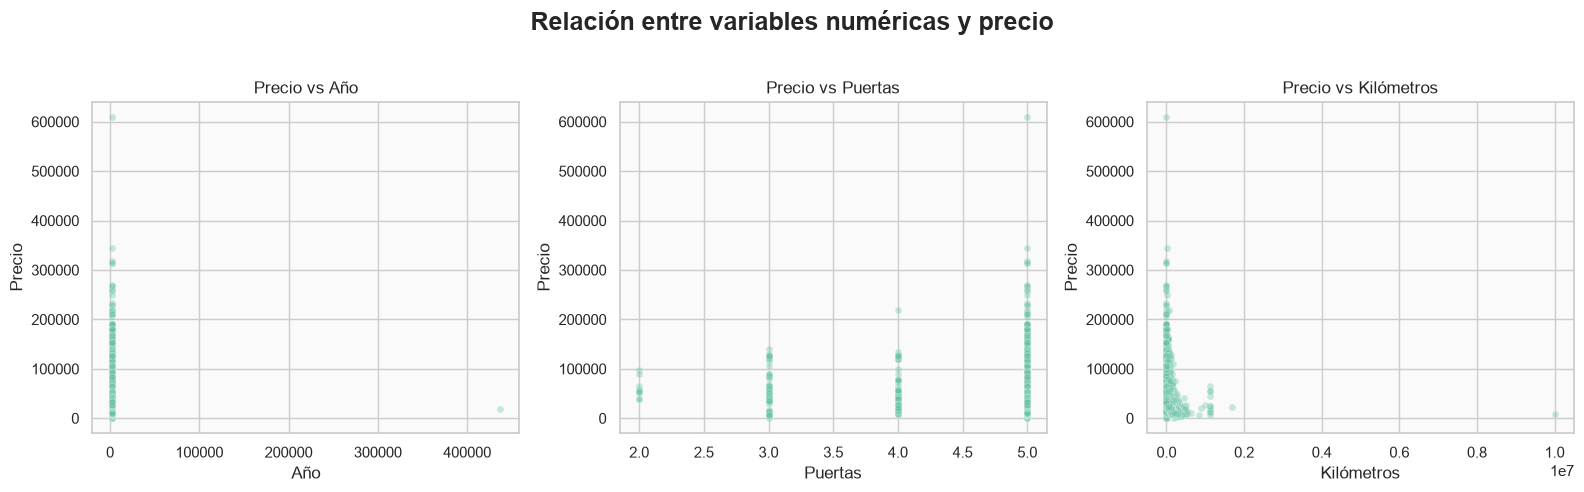

Relación de variables categóricas con el precio


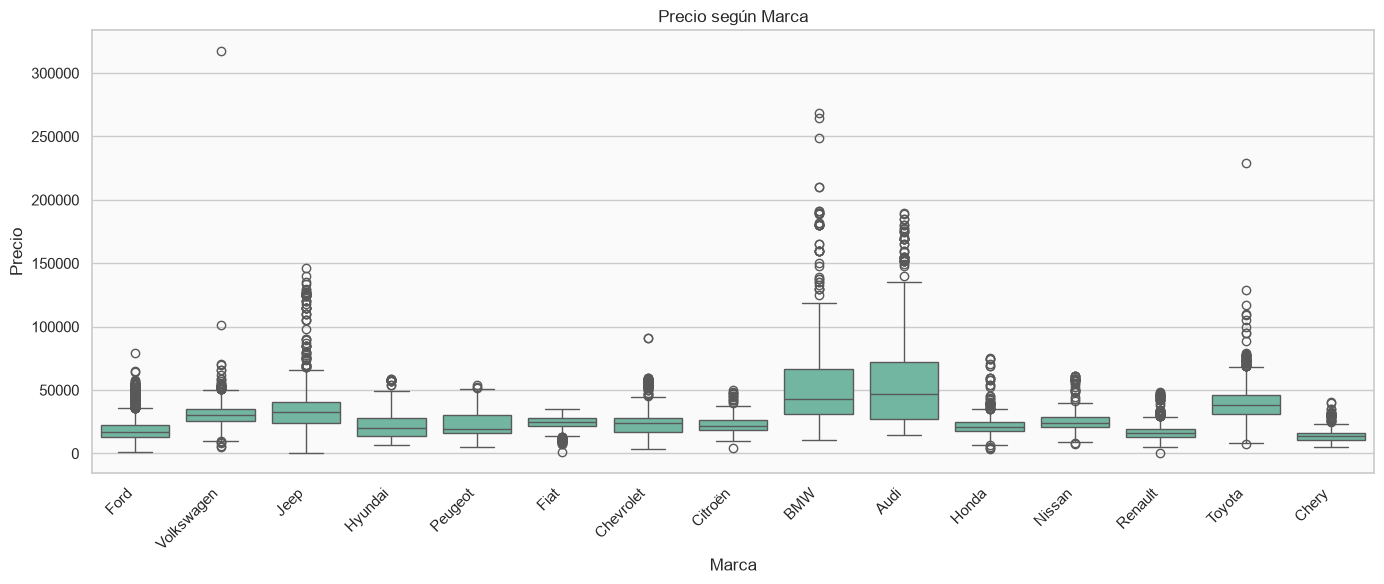

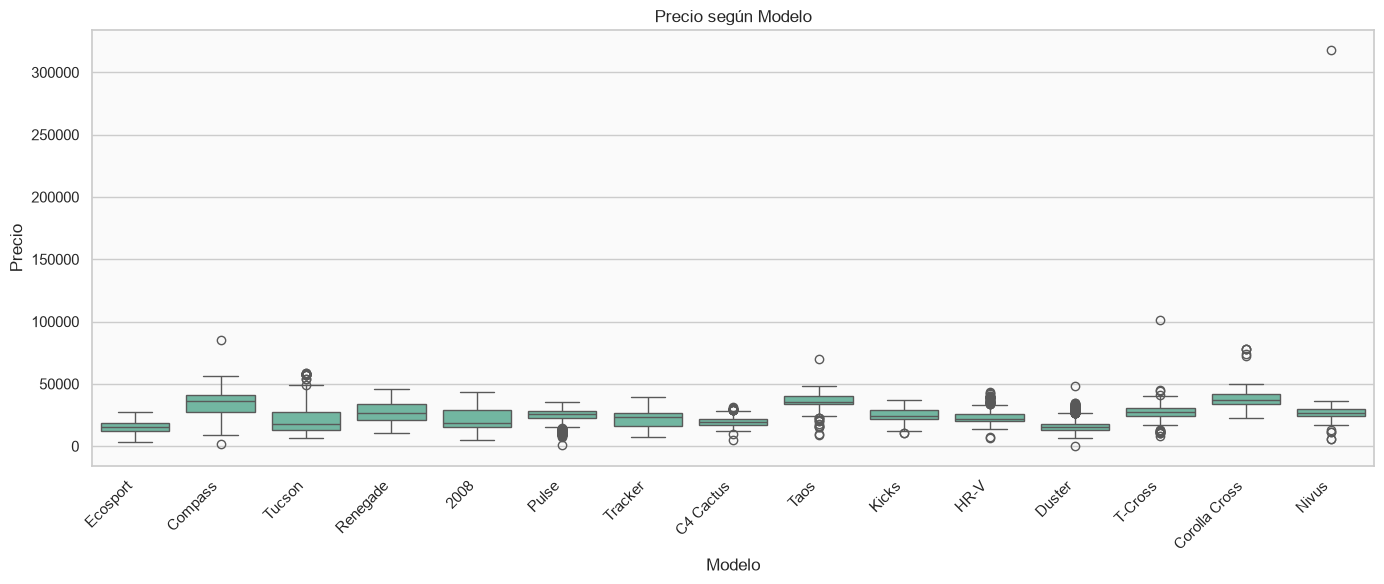

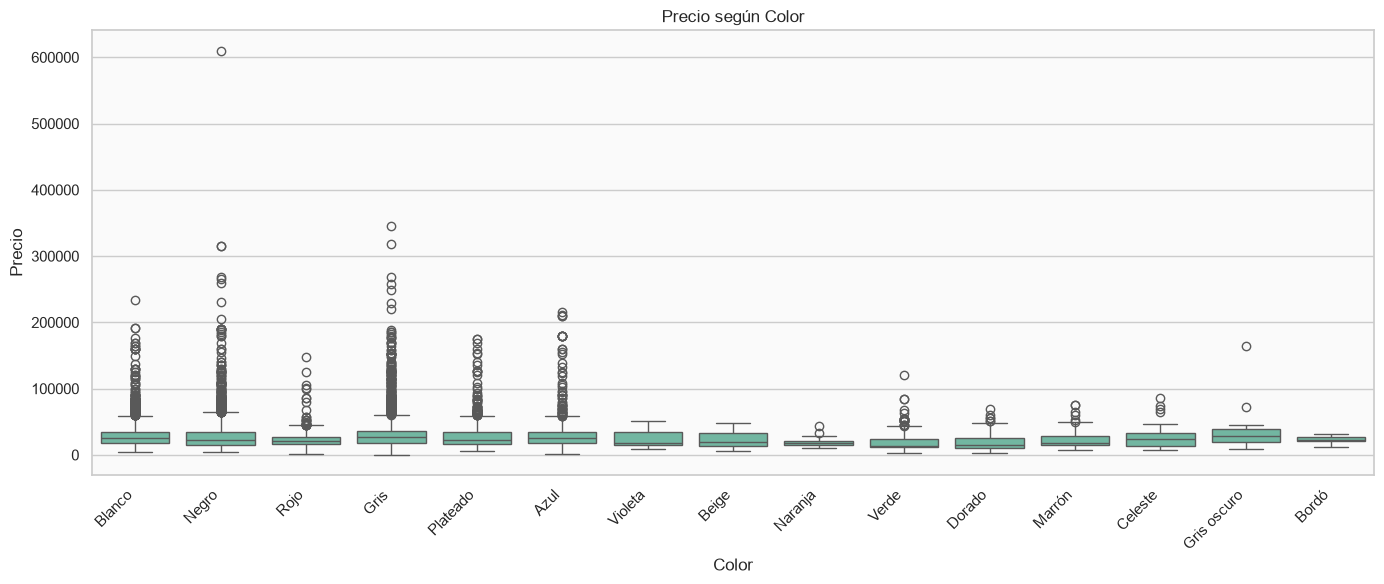

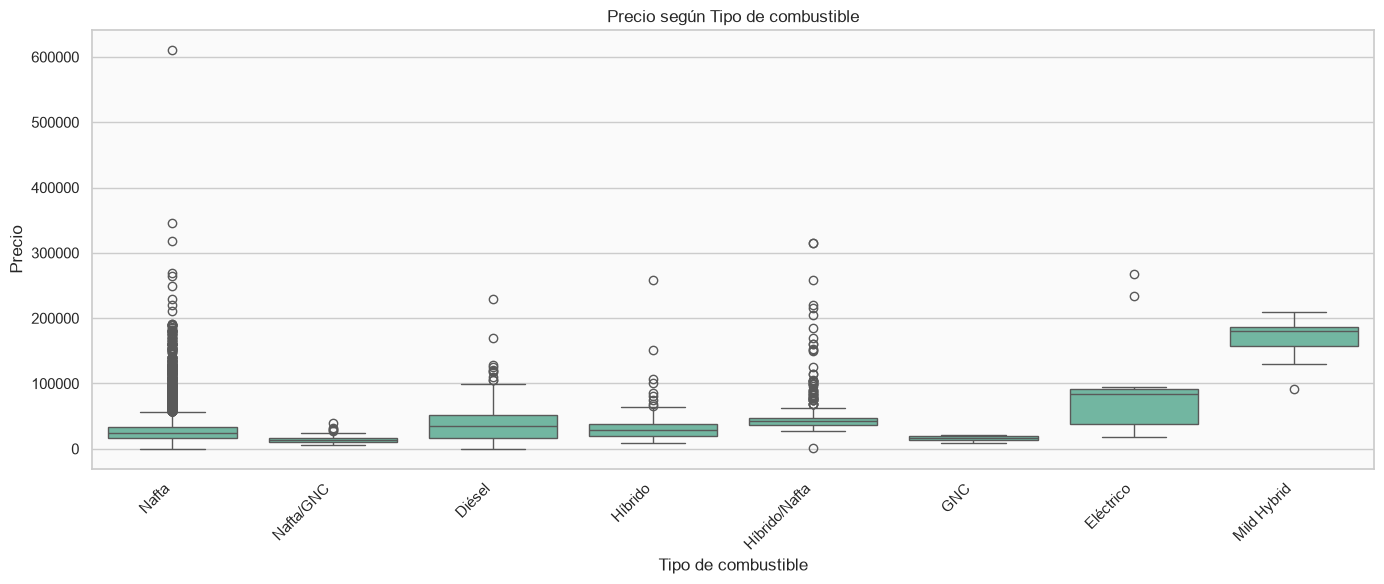

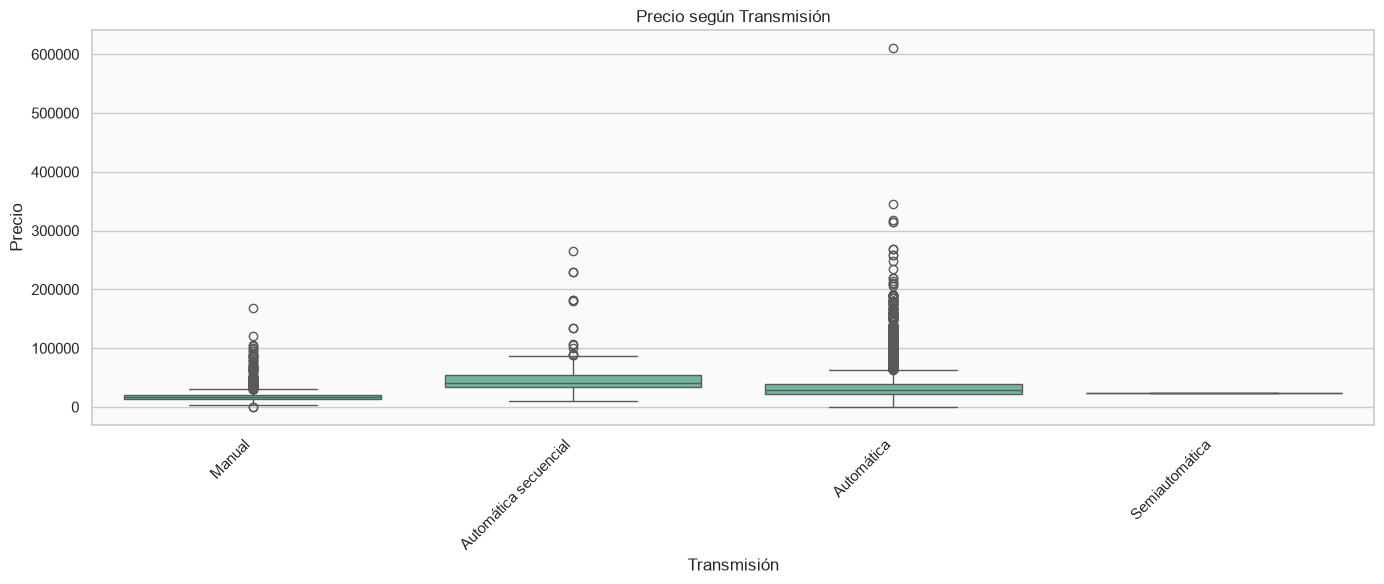

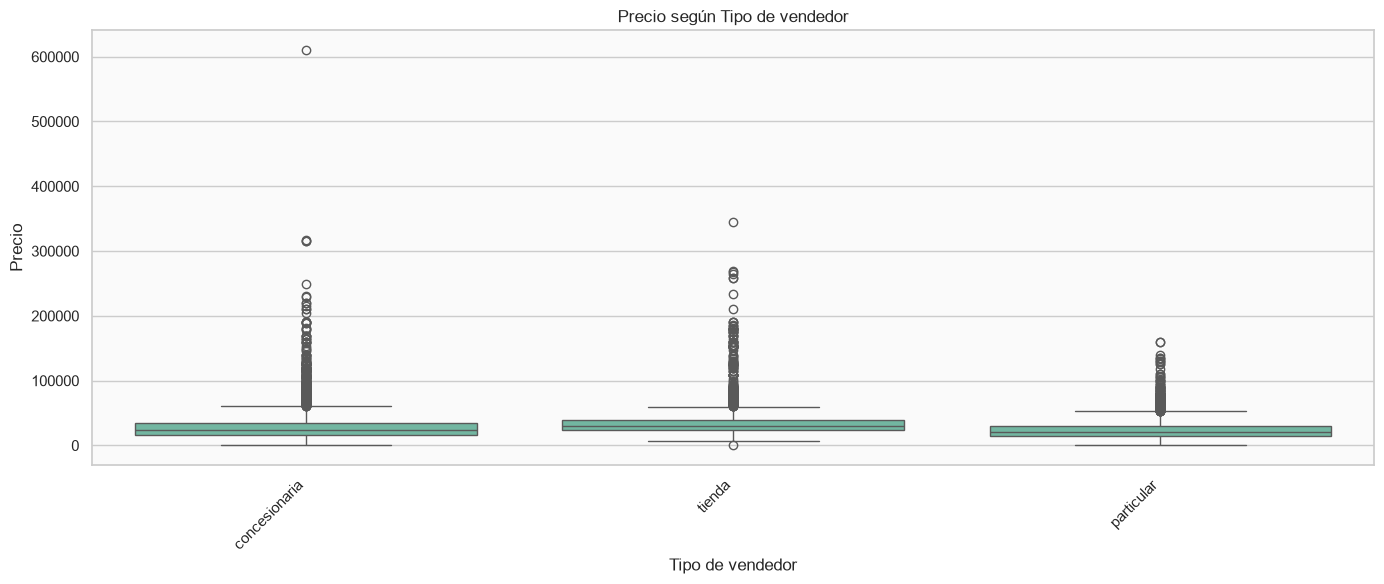

Matriz de correlación


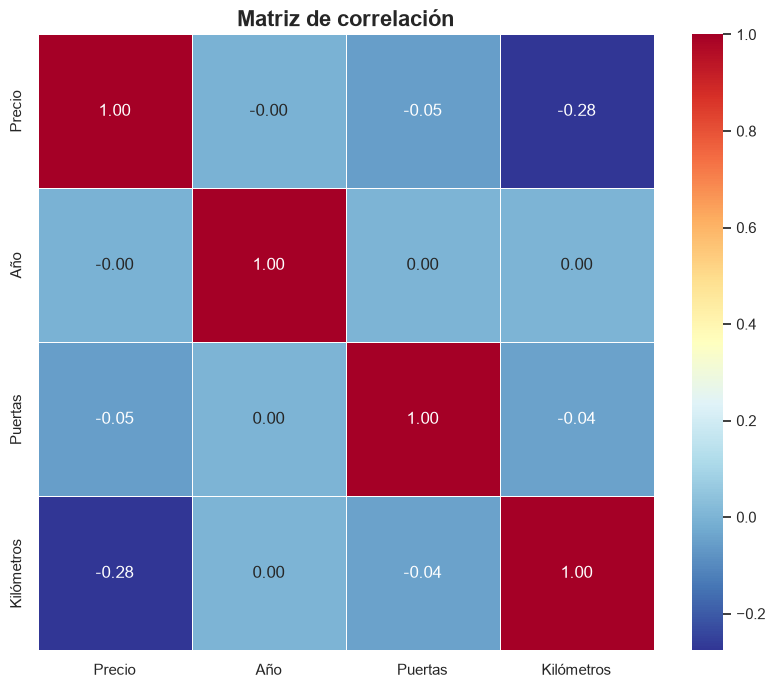

In [8]:
#meto plots
eda_visualizacion_suvs(data_pre, target= "Precio", show_pairplot= False)

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara"  evitando el data leakage.

In [9]:
train, val = train_val_split(data_pre)

Train set shape: (14572, 15), 
Validation set shape: (3644, 15)


### MODELS

### Comparison bewtween models

### Final Model